# 04 — Analysis (Explore & Interpret)

Ten questions answered from the enriched dataset built in notebooks 01–03.

**Data**: 333 race-editions across the Tour de France (1903–2026), Giro d'Italia (1909–2026)
and Vuelta a España (1935–2025), joined to biographical data for 156 of 161 riders.

**Filtering convention.** Every analysis states which rows it uses:

| Status | Rows | When it counts |
|---|---|---|
| `held` | 302 | Always |
| `disputed` | 7 | Route-level questions only (TdF 1999–2005 were raced; the results were annulled) |
| `no_race` | 23 | Never (no edition took place) |
| `team_only` | 1 | Route-level questions only (1912 Giro had no individual classification) |

This distinction matters: excluding 1999–2005 from a question about race distance would remove
seven editions that genuinely happened.

## Questions

**Rebuilt from the original project (Tour de France only, no Pandas):**
1. Which nationalities have produced the most Grand Tour winners?
2. Which riders have won most often, and when?
3. How have race distances evolved?
4. How do the most successful riders compare?
5. At what age do riders win?
6. Do the three races' distances correlate over time?
7. Has average winning speed converged across the races?
8. Which riders have won more than one different Grand Tour?
9. Is winner age trending upward, and is the trend meaningful?
10. Does each race have distinct eras of national dominance?

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["figure.dpi"] = 110

RACE_NAMES = {"tdf": "Tour de France", "giro": "Giro d'Italia", "vuelta": "Vuelta a España"}
RACE_COLOURS = {"tdf": "#F2C300", "giro": "#E8388A", "vuelta": "#C8102E"}

ed = pd.read_csv("../data/processed/editions_enriched.csv", parse_dates=["birth_date"])
riders = pd.read_csv("../data/processed/riders_enriched.csv", parse_dates=["birth_date"])

held = ed[ed["status"] == "held"]
raced = ed[ed["status"].isin(["held", "disputed", "team_only"])]

print(f"editions: {len(ed)}  |  held: {len(held)}  |  raced: {len(raced)}")

editions: 333  |  held: 294  |  raced: 302


## Q1 — Which nationalities have produced the most winners?

The original project answered this by scraping Wikipedia's pre-computed "by nationality"
summary table. Here the counts are derived from the edition-level data instead, which means
they can be broken down per race rather than only in total — and it removes the dependency on
a summary table whose column order differs between the three pages.

race           giro  tdf  vuelta  total
country                                
Italy            68   10       6     84
France            6   36       9     51
Spain             4   12      32     48
Belgium           7   18       8     33
Great Britain     3    6       3     12
Slovenia          2    5       4     11
Switzerland       3    2       5     10
Luxembourg        2    5       0      7
United States     1    3       2      6
Netherlands       1    2       2      5
Denmark           1    3       1      5
Colombia          2    1       2      5


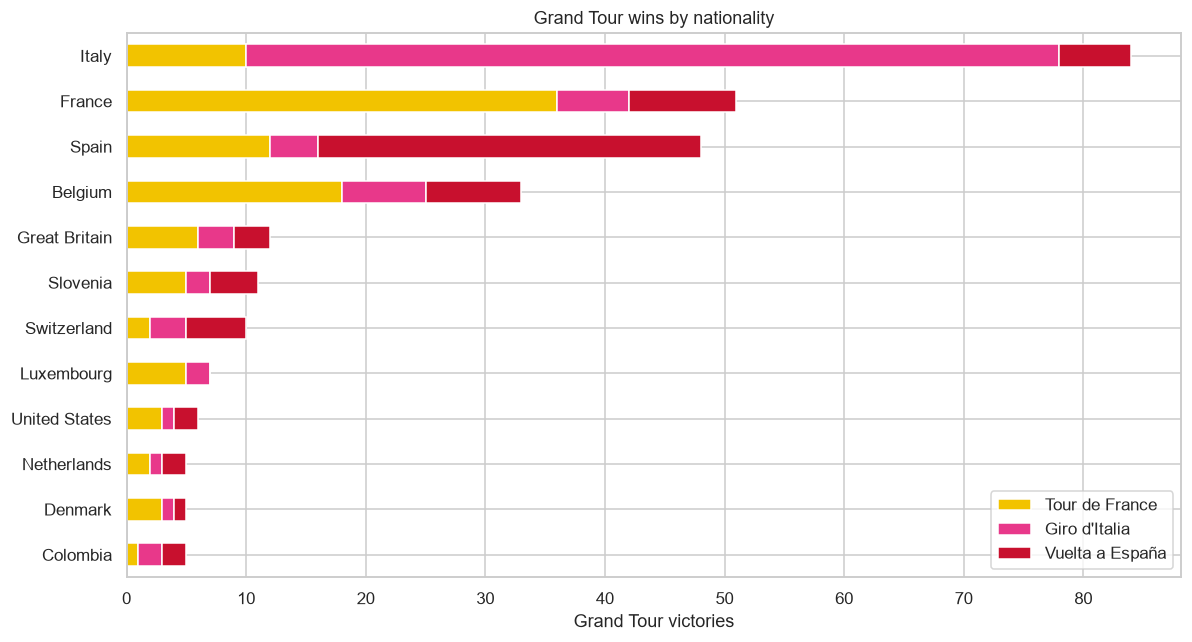

In [2]:
by_country = (held.groupby(["country", "race"]).size()
                  .unstack(fill_value=0)
                  .assign(total=lambda d: d.sum(axis=1))
                  .sort_values("total", ascending=False))

print(by_country.head(12))

top = by_country.head(12).drop(columns="total")
fig, ax = plt.subplots(figsize=(11, 6))
top[["tdf", "giro", "vuelta"]].plot(
    kind="barh", stacked=True, ax=ax,
    color=[RACE_COLOURS[r] for r in ["tdf", "giro", "vuelta"]],
)
ax.invert_yaxis()
ax.set_xlabel("Grand Tour victories")
ax.set_ylabel("")
ax.set_title("Grand Tour wins by nationality")
ax.legend([RACE_NAMES[r] for r in ["tdf", "giro", "vuelta"]], title="")
plt.tight_layout()
plt.show()

### Q1 findings

| Country | Total | TdF | Giro | Vuelta | Home race share |
|---|---|---|---|---|---|
| Italy | 84 | 10 | **68** | 6 | 81% |
| France | 51 | **36** | 6 | 9 | 71% |
| Spain | 48 | 12 | 4 | **32** | 67% |
| Belgium | 33 | 18 | 7 | 8 | — |

**The home-race effect dominates.** Each of the three cycling nations wins overwhelmingly at
home: Italy takes 81% of its Grand Tour victories at the Giro, France 71% at the Tour, Spain
67% at the Vuelta. This is a pattern the original project could not have detected, because
with a single race there is nothing to compare against.

**Belgium is the exception that clarifies the rule.** With 33 wins and no home Grand Tour, its
victories spread 18/7/8 across the three races. Belgian success is not concentrated anywhere,
which suggests the home advantage is about participation and selection — riders target their
national race — rather than about the terrain favouring locals.

**Note on nationality data.** Country here is the flag shown in the results table, which reflects
the licence the rider raced under. Wikidata's citizenship data (collected in notebook 03) is
messier and often multi-valued: pre-1946 Italian riders hold both *Italy* and *Kingdom of Italy*,
Soviet-era riders both *Russia* and *Soviet Union*, and Chris Froome both *Kenya* and
*United Kingdom*. The race-table nationality is the more consistent choice for counting wins.

## Q2 — Which riders have won most often, and when?

The original project answered this for the Tour de France alone, reading from a pre-built
JSON file of multiple winners. Here it comes from the edition data directly, so a rider's
victories can be shown across all three races on one timeline.

In [3]:
top_riders = riders.nlargest(12, "wins_total")[
    ["rider_name", "country", "wins_tdf", "wins_giro", "wins_vuelta", "wins_total", "races_won"]
]
print(top_riders.to_string(index=False))

      rider_name       country  wins_tdf  wins_giro  wins_vuelta  wins_total  races_won
     Eddy Merckx       Belgium         5          5            1          11          3
 Bernard Hinault        France         5          3            2          10          3
Jacques Anquetil        France         5          2            1           8          3
Alberto Contador         Spain         2          2            3           7          3
    Chris Froome Great Britain         4          1            2           7          3
    Fausto Coppi         Italy         2          5            0           7          2
   Tadej Pogačar      Slovenia         5          1            0           6          2
   Alfredo Binda         Italy         0          5            0           5          1
  Felice Gimondi         Italy         1          3            1           5          3
    Gino Bartali         Italy         2          3            0           5          2
 Miguel Induráin         Spain  

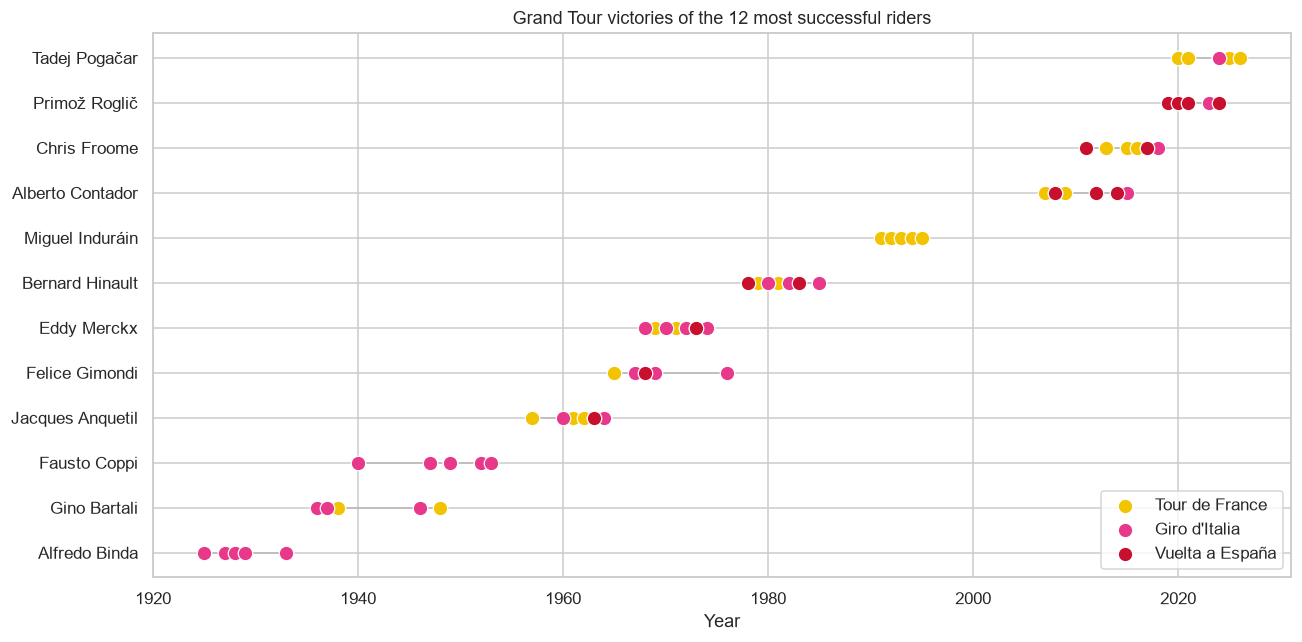

In [4]:
names = top_riders["rider_name"].tolist()
sub = held[held["rider_name"].isin(names)]

# order riders by the year of their first win, so the chart reads chronologically
order = sub.groupby("rider_name")["year"].min().sort_values().index.tolist()
y_pos = {name: i for i, name in enumerate(order)}

fig, ax = plt.subplots(figsize=(12, 6))

for race in ["tdf", "giro", "vuelta"]:
    r = sub[sub["race"] == race]
    ax.scatter(r["year"], [y_pos[n] for n in r["rider_name"]],
               s=90, color=RACE_COLOURS[race], label=RACE_NAMES[race],
               edgecolor="white", linewidth=0.8, zorder=3)

# a faint line spanning each rider's career
for name in order:
    yrs = sub[sub["rider_name"] == name]["year"]
    ax.plot([yrs.min(), yrs.max()], [y_pos[name]] * 2,
            color="grey", alpha=0.35, linewidth=1, zorder=1)

ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.set_xlabel("Year")
ax.set_title("Grand Tour victories of the 12 most successful riders")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Q2 findings

| Rider | Country | Total | TdF | Giro | Vuelta | Races won |
|---|---|---|---|---|---|---|
| Eddy Merckx | Belgium | 11 | 5 | 5 | 1 | 3 |
| Bernard Hinault | France | 10 | 5 | 3 | 2 | 3 |
| Jacques Anquetil | France | 8 | 5 | 2 | 1 | 3 |
| Alberto Contador | Spain | 7 | 2 | 2 | 3 | 3 |
| Chris Froome | Great Britain | 7 | 4 | 1 | 2 | 3 |
| Fausto Coppi | Italy | 7 | 2 | 5 | 0 | 2 |

**Merckx leads on total victories with 11**, and is one of only three riders to reach five wins
in two different Grand Tours.

**The timeline shows two distinct shapes of dominance.** Merckx's eleven wins fall inside seven
years (1968–1974); Contador's seven span nine (2007–2015), and Froome's seven span eight. The
earlier riders won more, faster. Whether that reflects deeper modern fields, greater
specialisation, or simply more riders targeting single races is not answerable from this data,
but the compression is visible.

**Specialists versus all-rounders.** Two riders in the top twelve won only one race:
Miguel Induráin (5 Tours, nothing else) and Alfredo Binda (5 Giri, nothing else). Six of the
twelve won all three. The chart's colour composition separates these immediately — Induráin's
row is entirely yellow, Binda's entirely pink, while Hinault's and Contador's alternate.

**Eras are visible as gaps.** No rider in this group has victories spanning 1996–2006, the
decade whose Tour results were later annulled or reassigned. The absence is a consequence of
the data-quality decisions made in notebook 02, not of the sport pausing.

## Q3 — How have race distances evolved?

The original project plotted Tour de France distance against year as a scatter and observed
that it fell. With three races the question becomes sharper: did they all shrink, at the same
time, and by the same amount?

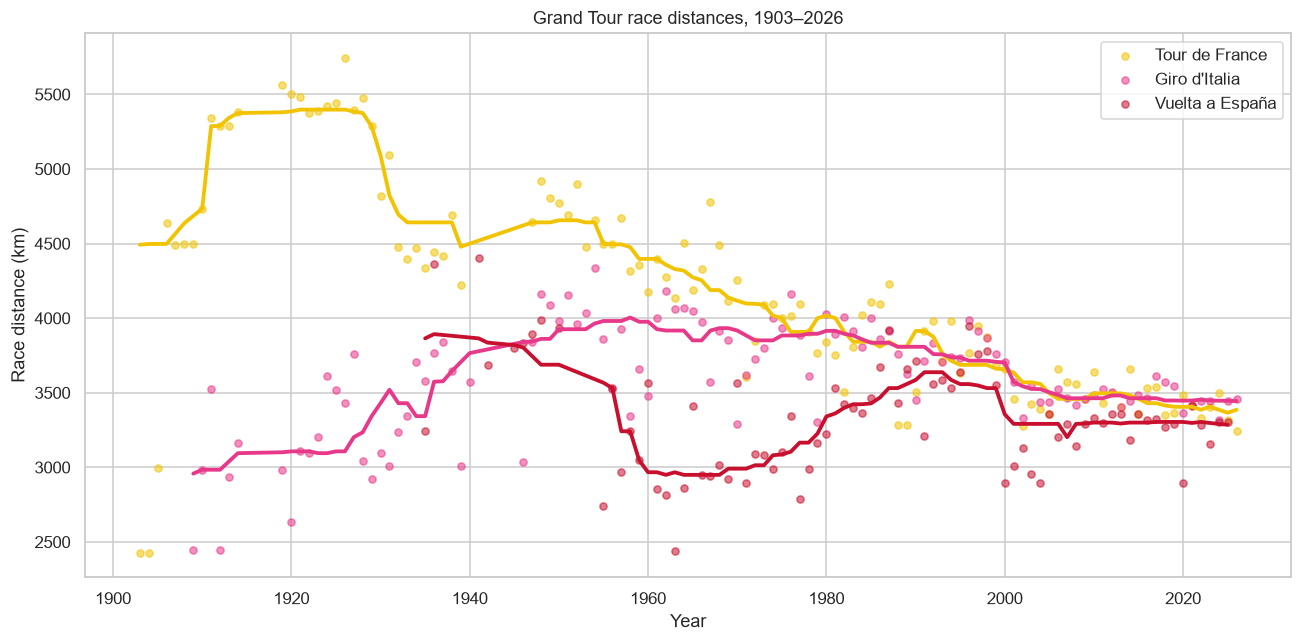

        count    mean    std     min     25%     50%     75%     max
race                                                                
giro    109.0  3590.0  368.0  2443.0  3430.0  3577.0  3868.0  4337.0
tdf     113.0  4159.0  713.0  2428.0  3559.0  4098.0  4637.0  5745.0
vuelta   80.0  3331.0  365.0  2442.0  3073.0  3304.0  3551.0  4406.0


In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

for race in ["tdf", "giro", "vuelta"]:
    sub = raced[(raced["race"] == race) & raced["distance_km"].notna()]
    ax.scatter(sub["year"], sub["distance_km"], s=22, alpha=0.55,
               color=RACE_COLOURS[race], label=RACE_NAMES[race])

    # 30-year rolling median shows the trend without assuming a shape
    smooth = sub.sort_values("year").set_index("year")["distance_km"].rolling(15, center=True, min_periods=5).median()
    ax.plot(smooth.index, smooth.values, color=RACE_COLOURS[race], linewidth=2.5)

ax.set_xlabel("Year")
ax.set_ylabel("Race distance (km)")
ax.set_title("Grand Tour race distances, 1903–2026")
ax.legend()
plt.tight_layout()
plt.show()

print(raced.groupby("race")["distance_km"].describe().round(0))

### Q3 findings

| Race | Editions | Mean | Std | Min | Max |
|---|---|---|---|---|---|
| Tour de France | 113 | 4,159 km | 713 | 2,428 | 5,745 |
| Giro d'Italia | 109 | 3,590 km | 368 | 2,443 | 4,337 |
| Vuelta a España | 80 | 3,331 km | 365 | 2,442 | 4,406 |

**The three races have converged.** They began at very different lengths — the Tour peaked
above 5,700 km in the 1920s while the Giro sat near 3,100 km — and since roughly 2000 all
three have settled into a narrow band around 3,300–3,500 km. The rolling medians, which were
separated by more than 2,000 km in the 1920s, are now within about 200 km of each other.

**The Tour's variability is the story.** Its standard deviation (713 km) is roughly double the
other two (368 and 365). The Tour was the race that changed most: a sharp climb to ~5,400 km
between 1910 and 1926, then a steep drop around 1930, then a long steady decline. The Giro and
Vuelta were never as long and never varied as much.

**Convergence suggests regulation, not coincidence.** Three independently organised races,
in three countries, arriving at nearly the same length is more consistent with a governing
constraint — the UCI caps Grand Tour length and stage distances — than with three organisers
independently reaching the same conclusion.

**What the original project could see, and what it could not.** Plotting the Tour alone shows
a decline and invites the explanation "races got shorter as they got faster." Plotting all
three shows the decline is mostly a *Tour* phenomenon: the Giro fell by roughly 500 km across
its whole history, the Tour by nearly 2,000. A single-race view would have generalised a
pattern that is largely specific to one race.

**Methodological note.** The trend lines are 15-year rolling medians, not fitted regressions.
The Tour's history is clearly not linear — it rises, drops sharply, then declines — so imposing
a straight line would have described none of those phases. Letting the data show its shape
before choosing a model is the right order of operations.

## Q4 — How do the most successful riders compare?

The original project compared the five-time Tour winners by total winning time in minutes.
That comparison has a flaw: winning time measures route length as much as rider performance.
Anquetil's 1957 Tour took longer than Induráin's 1995 Tour largely because it was 800 km longer.

Average speed removes route length from the comparison, and extending to all three races means
riders can be compared across the Grand Tours they actually rode rather than one only.

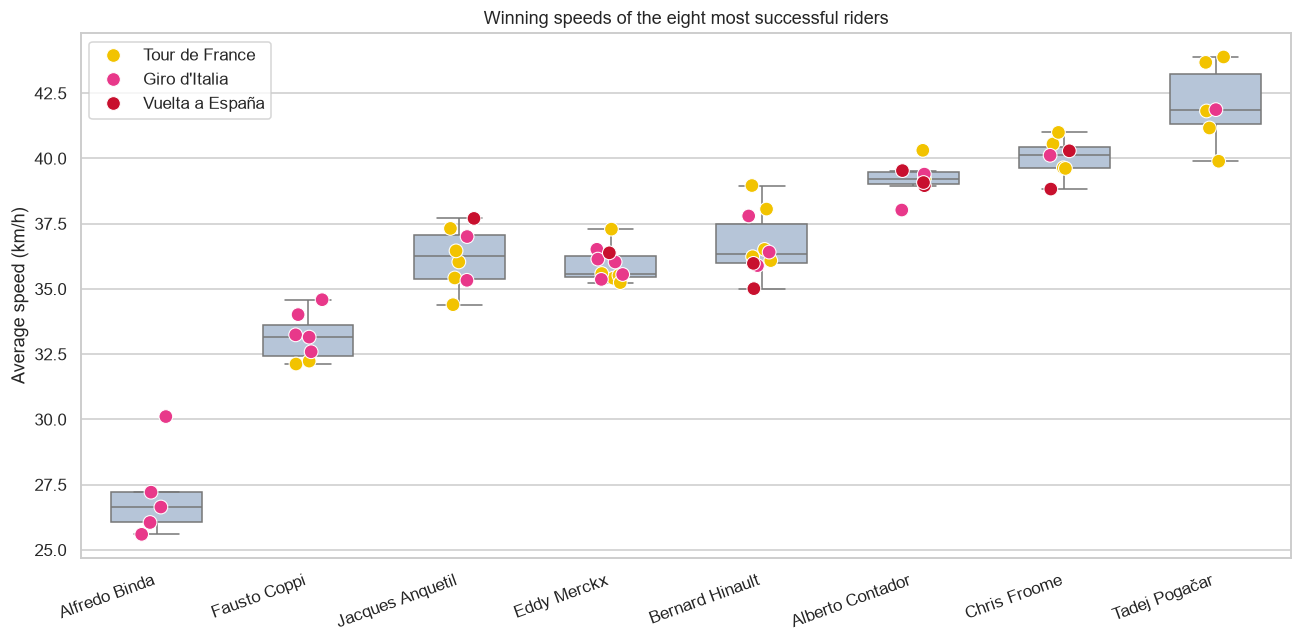

                  count   mean    min    max
rider_name                                  
Alfredo Binda         5  27.12  25.60  30.11
Fausto Coppi          7  33.13  32.12  34.59
Jacques Anquetil      8  36.21  34.40  37.70
Eddy Merckx          11  35.91  35.24  37.29
Bernard Hinault      10  36.69  35.01  38.96
Alberto Contador      7  39.22  38.02  40.31
Chris Froome          7  40.01  38.83  41.00
Tadej Pogačar         6  42.05  39.89  43.89


In [6]:
names = riders.nlargest(8, "wins_total")["rider_name"].tolist()
sub = held[held["rider_name"].isin(names) & held["avg_speed_kmh"].notna()]

order = sub.groupby("rider_name")["year"].min().sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=sub, x="rider_name", y="avg_speed_kmh", order=order,
            color="lightsteelblue", width=0.6, ax=ax, showfliers=False)
sns.stripplot(data=sub, x="rider_name", y="avg_speed_kmh", order=order,
              hue="race", palette=RACE_COLOURS, size=9,
              edgecolor="white", linewidth=0.7, ax=ax)

ax.set_xlabel("")
ax.set_ylabel("Average speed (km/h)")
ax.set_title("Winning speeds of the eight most successful riders")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, [RACE_NAMES.get(l, l) for l in labels], title="", loc="upper left")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

print(sub.groupby("rider_name")["avg_speed_kmh"]
        .agg(["count", "mean", "min", "max"]).round(2)
        .reindex(order).to_string())

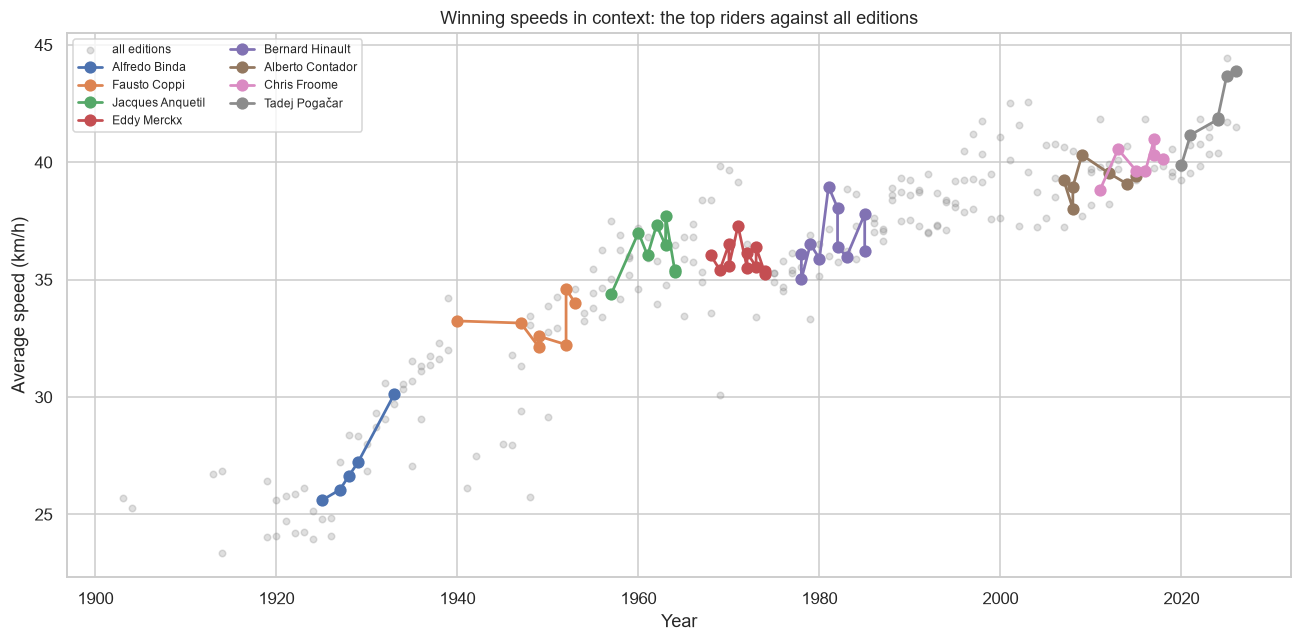

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

allsp = held[held["avg_speed_kmh"].notna()]
ax.scatter(allsp["year"], allsp["avg_speed_kmh"], s=18, alpha=0.25,
           color="grey", label="all editions")

for name in order:
    r = sub[sub["rider_name"] == name].sort_values("year")
    ax.plot(r["year"], r["avg_speed_kmh"], marker="o", linewidth=1.8,
            markersize=7, label=name)

ax.set_xlabel("Year")
ax.set_ylabel("Average speed (km/h)")
ax.set_title("Winning speeds in context: the top riders against all editions")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

### Q4 findings

| Rider | Wins | Mean speed | Range |
|---|---|---|---|
| Alfredo Binda | 5 | 27.12 km/h | 25.60–30.11 |
| Fausto Coppi | 7 | 33.13 | 32.12–34.59 |
| Jacques Anquetil | 8 | 36.21 | 34.40–37.70 |
| Eddy Merckx | 11 | 35.91 | 35.24–37.29 |
| Bernard Hinault | 10 | 36.69 | 35.01–38.96 |
| Alberto Contador | 7 | 39.22 | 38.02–40.31 |
| Chris Froome | 7 | 40.01 | 38.83–41.00 |
| Tadej Pogačar | 6 | 42.05 | 39.89–43.89 |

**Read alone, the first chart says Pogačar is 55% faster than Binda. That conclusion is wrong**,
and the second chart shows why: the ordering is almost perfectly chronological. The riders are
sorted by era, and speed rises monotonically with era. What the boxplot measures is the year
each rider competed, not their ability.

**Against their contemporaries, the picture changes completely.** Plotted over all editions,
every one of these riders sits at or slightly above the cloud of their own era — but none is a
dramatic outlier. Binda's 27 km/h in the late 1920s was at the top of what was possible then;
Pogačar's 42 km/h is at the top of what is possible now. The gap between them is equipment,
road surfaces, nutrition and race design, not physiology.

**Merckx is the interesting case.** His mean (35.91) is *lower* than Anquetil's (36.21) despite
racing a decade later, and his range is the narrowest of any rider here (35.24–37.29, just
2 km/h). Two readings are possible: he won consistently rather than spectacularly, or his 11
wins across all three races included slower editions that riders with fewer wins avoided.
Distinguishing these would need per-edition field data this dataset does not contain.

**The methodological point.** The original project compared five-time Tour winners by total
minutes and concluded Induráin was fastest. That comparison confounds rider speed with route
length. Switching to km/h removes route length — but as the second chart shows, it does not
remove the era effect. **Cross-era comparison of athletes is not possible from results data
alone**, and the honest answer to "who was fastest" is that the question is not well-posed.

## Q5 — At what age do riders win?

The original project computed age as `winning_year − birth_year`, which is off by up to a
year depending on whether the rider's birthday had passed. Here age is computed from the
actual race end date against the full birth date.

The calculation validates against three independently documented records: Henri Cornet
19.97 years at the 1904 Tour (Wikipedia: "just short of his 20th birthday"), Fausto Coppi
20.71 at the 1940 Giro ("20 years, 158 days"), and Firmin Lambot 36.36 at the 1922 Tour
("36 years, 4 months").

Editions with a known age: 288 of 294

count    288.00
mean      27.92
std        3.33
min       19.97
25%       25.58
50%       27.74
75%       30.18
max       41.90
Name: age_at_win, dtype: float64


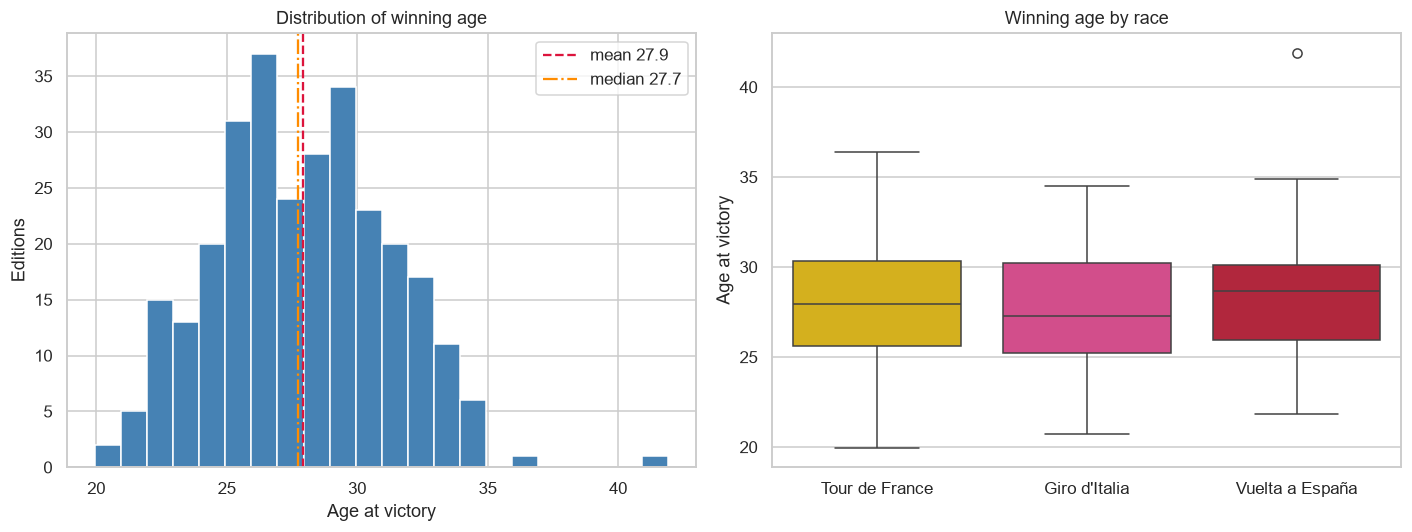


By race:
        count   mean  median   std
race                              
giro      106  27.59   27.28  3.33
tdf       106  27.97   27.93  3.35
vuelta     76  28.31   28.68  3.31


In [9]:
aged = held[held["age_at_win"].notna()]
print(f"Editions with a known age: {len(aged)} of {len(held)}\n")
print(aged["age_at_win"].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(aged["age_at_win"], bins=22, edgecolor="white", color="steelblue")
axes[0].axvline(aged["age_at_win"].mean(), color="crimson", linestyle="--",
                label=f"mean {aged['age_at_win'].mean():.1f}")
axes[0].axvline(aged["age_at_win"].median(), color="darkorange", linestyle="-.",
                label=f"median {aged['age_at_win'].median():.1f}")
axes[0].set_xlabel("Age at victory")
axes[0].set_ylabel("Editions")
axes[0].set_title("Distribution of winning age")
axes[0].legend()

sns.boxplot(data=aged, x="race", y="age_at_win", ax=axes[1],
            hue="race", palette=RACE_COLOURS, legend=False,
            order=["tdf", "giro", "vuelta"])

axes[1].set_xticks(range(3))
axes[1].set_xticklabels([RACE_NAMES[r] for r in ["tdf", "giro", "vuelta"]])
axes[1].set_xlabel("")
axes[1].set_ylabel("Age at victory")
axes[1].set_title("Winning age by race")

plt.tight_layout()
plt.show()

print("\nBy race:")
print(aged.groupby("race")["age_at_win"].agg(["count", "mean", "median", "std"]).round(2))

### Q5 findings

Winning age is **remarkably stable**: mean 27.9, median 27.7, standard deviation 3.3 years.
Half of all Grand Tour victories come from riders aged 25.6 to 30.2. The distribution is close
to symmetric with a slight right tail — a few late winners, no early ones, which is what a
biological floor on physical maturity would produce.

**The three races are nearly identical:**

| Race | n | Mean | Median | Std |
|---|---|---|---|---|
| Giro d'Italia | 106 | 27.59 | 27.28 | 3.33 |
| Tour de France | 106 | 27.97 | 27.93 | 3.35 |
| Vuelta a España | 76 | 28.31 | 28.68 | 3.31 |

The Vuelta's winners are on average 0.7 years older than the Giro's. That ordering is
plausible — the Vuelta runs in September and has historically been a target for riders whose
season went wrong earlier — but 0.7 years against a standard deviation of 3.3 is a small
difference on a modest sample. It is suggestive, not established. Q9 tests whether age trends
are meaningful using a proper null model.

**The extremes are the interesting part.** Chris Horner won the 2013 Vuelta at 41.9, more than
five years older than any other Grand Tour winner and clearly separated as an outlier on the
boxplot. At the other end, Henri Cornet (19.97, 1904 Tour) and Fausto Coppi (20.71, 1940 Giro)
are the only winners under 21.

**Coverage**: 288 of 294 held editions have a computable age. The six gaps are riders whose
Wikidata match failed (documented in notebook 03).